# 🚂 Amtrak Delay Patterns — Web Scraping & Data Analysis

**STA 220 — Data & Web Technologies for Data Analysis**

This project combines **web scraping**, **SQL databases**, and **data visualization** to analyze Amtrak train delay patterns across the United States.

### Data Sources
| Source | Method | Data |
|--------|--------|------|
| **Amtraker API** | `requests` (JSON) | Real-time train positions, scheduled vs. actual times, delays |
| **Wikipedia** | `pd.read_html` + `lxml` | Station metadata (ridership, state, coordinates) |
| **Open-Meteo API** | `requests` (JSON) | Historical weather data for delay correlation |

### Tools & Libraries
- **Scraping**: `requests`, `lxml`, `pandas.read_html`
- **Database**: `sqlite3`
- **Visualization**: `plotly`, `matplotlib`, `folium`
- **Statistics**: `scipy.stats`, `numpy`

In [1]:
#!pip3 install requests lxml pandas matplotlib plotly folium scipy numpy requests-cache
!pip3 install nbformat


In [2]:
import requests
import requests_cache
import sqlite3
import time
import json
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import MarkerCluster
from datetime import datetime, timezone, timedelta
from scipy import stats

# styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# request caching to be polite
requests_cache.install_cache("amtrak_cache", expire_after=300)

# headers — always identify yourself
HEADERS = {
    "User-Agent": "STA220-AmtrakProject/1.0 (UC Davis Student Project)"
}

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


---
# Part 1 — Web Scraping 🕸️

We scrape data from three sources:
1. **Amtraker API** — Real-time train tracking data (JSON API)
2. **Wikipedia** — Station metadata tables (HTML scraping with `pd.read_html`)
3. **Open-Meteo API** — Historical weather data (JSON API)

## 1.1 Scraping Real-Time Train Data (Amtraker API)

The [Amtraker API](https://amtraker.com) provides real-time tracking data for all active Amtrak trains. The API returns JSON with scheduled and actual arrival/departure times for every station stop.

**Key fields:**
- `schArr` / `schDep` — Scheduled arrival/departure (ISO 8601)
- `arr` / `dep` — Actual arrival/departure
- `routeName` — The Amtrak route (e.g., "Southwest Chief", "Coast Starlight")
- `lat` / `lon` — Current GPS position
- `velocity` — Speed in mph

In [3]:
# fetch all currently active trains from the Amtraker API
API_URL = "https://api-v3.amtraker.com/v3/trains"

response = requests.get(API_URL, headers=HEADERS, timeout=30)
response.raise_for_status() 
print(f"Status: {response.status_code}")
print(f"Content-Type: {response.headers.get('Content-Type')}")

data = response.json()
print(f"\nNumber of train numbers in response: {len(data)}")
print(f"Sample train numbers: {list(data.keys())[:10]}")

Status: 200
Content-Type: application/json

Number of train numbers in response: 161
Sample train numbers: ['1', '2', '3', '4', '5', '6', '7', '8', '11', '14']


In [4]:
# inspect a single train's data structure
sample_key = list(data.keys())[0]
sample_train = data[sample_key][0]

print(f"Route: {sample_train['routeName']}")
print(f"Train #: {sample_train['trainNum']}")
print(f"From: {sample_train['origName']} → To: {sample_train['destName']}")
print(f"Current position: ({sample_train['lat']:.4f}, {sample_train['lon']:.4f})")
print(f"Speed: {sample_train['velocity']:.1f} mph")
print(f"State: {sample_train['trainState']}")
print(f"\nNumber of stations on route: {len(sample_train['stations'])}")

# show first 3 stations
print("\nFirst 3 station stops:")
for s in sample_train['stations'][:3]:
    print(f"  {s['name']} ({s['code']}) — Status: {s['status']}")
    print(f"    Scheduled Arr: {s['schArr']}")
    print(f"    Actual Arr:    {s['arr']}")

Route: Sunset Limited
Train #: 1
From: New Orleans → To: Los Angeles Union
Current position: (29.9188, -90.2100)
Speed: 9.0 mph
State: Active

Number of stations on route: 22

First 3 station stops:
  New Orleans (NOL) — Status: Departed
    Scheduled Arr: 2026-02-28T09:00:00-06:00
    Actual Arr:    2026-02-28T09:00:00-06:00
  Schriever (SCH) — Status: Enroute
    Scheduled Arr: 2026-02-28T10:30:00-06:00
    Actual Arr:    2026-02-28T10:41:00-06:00
  New Iberia (NIB) — Status: Enroute
    Scheduled Arr: 2026-02-28T11:56:00-06:00
    Actual Arr:    2026-02-28T12:04:00-06:00


### Parsing Delay Data

For each station stop, we calculate the **delay in minutes** as:

$$\text{delay} = \text{actual\_time} - \text{scheduled\_time}$$

A positive value means the train is **late**, negative means **early**.

In [5]:
def parse_delay_minutes(scheduled, actual):
    """Calculate delay in minutes between scheduled and actual times."""
    if not scheduled or not actual:
        return None
    try:
        sch = datetime.fromisoformat(scheduled)
        act = datetime.fromisoformat(actual)
        delta = (act - sch).total_seconds() / 60.0
        return round(delta, 1)
    except (ValueError, TypeError):
        return None


def parse_all_trains(api_data):
    """Parse the full API response into a flat list of station-level delay records."""
    records = []
    scrape_time = datetime.now(timezone.utc).isoformat()
    
    for train_num, train_list in api_data.items():
        for train in train_list:
            route = train.get("routeName", "Unknown")
            tid = train.get("trainID", "")
            lat = train.get("lat")
            lon = train.get("lon")
            velocity = train.get("velocity")
            state = train.get("trainState", "")
            orig = train.get("origName", "")
            dest = train.get("destName", "")
            
            for station in train.get("stations", []):
                sch_arr = station.get("schArr", "")
                act_arr = station.get("arr", "")
                sch_dep = station.get("schDep", "")
                act_dep = station.get("dep", "")
                
                records.append({
                    "scrape_time": scrape_time,
                    "train_number": train.get("trainNum", train_num),
                    "train_id": tid,
                    "route_name": route,
                    "origin": orig,
                    "destination": dest,
                    "station_code": station.get("code", ""),
                    "station_name": station.get("name", ""),
                    "station_tz": station.get("tz", ""),
                    "scheduled_arrival": sch_arr,
                    "actual_arrival": act_arr,
                    "scheduled_departure": sch_dep,
                    "actual_departure": act_dep,
                    "delay_arrival_min": parse_delay_minutes(sch_arr, act_arr),
                    "delay_departure_min": parse_delay_minutes(sch_dep, act_dep),
                    "status": station.get("status", ""),
                    "train_lat": lat,
                    "train_lon": lon,
                    "velocity": velocity,
                    "train_state": state,
                })
    
    return pd.DataFrame(records)


# parse the API data
df_trains = parse_all_trains(data)
print(f"Parsed {len(df_trains)} station-stop records from {df_trains['train_id'].nunique()} trains")
print(f"Routes: {df_trains['route_name'].nunique()} unique routes")
print(f"Stations: {df_trains['station_code'].nunique()} unique stations")
df_trains.head()

Parsed 3235 station-stop records from 174 trains
Routes: 51 unique routes
Stations: 778 unique stations


,scrape_time,train_number,train_id,route_name,origin,destination,station_code,station_name,station_tz,scheduled_arrival,actual_arrival,scheduled_departure,actual_departure,delay_arrival_min,delay_departure_min,status,train_lat,train_lon,velocity,train_state
0,2026-02-28T16:04:29.399458+00:00,1,1-28,Sunset Limited,New Orleans,Los Angeles Union,NOL,New Orleans,America/Chicago,2026-02-28T09:00:00-06:00,2026-02-28T09:00:00-06:00,2026-02-28T09:00:00-06:00,2026-02-28T09:00:00-06:00,0.0,0.0,Departed,29.918775,-90.209982,8.985024,Active
1,2026-02-28T16:04:29.399458+00:00,1,1-28,Sunset Limited,New Orleans,Los Angeles Union,SCH,Schriever,America/Chicago,2026-02-28T10:30:00-06:00,2026-02-28T10:41:00-06:00,2026-02-28T10:30:00-06:00,2026-02-28T10:41:00-06:00,11.0,11.0,Enroute,29.918775,-90.209982,8.985024,Active
2,2026-02-28T16:04:29.399458+00:00,1,1-28,Sunset Limited,New Orleans,Los Angeles Union,NIB,New Iberia,America/Chicago,2026-02-28T11:56:00-06:00,2026-02-28T12:04:00-06:00,2026-02-28T11:56:00-06:00,2026-02-28T12:04:00-06:00,8.0,8.0,Enroute,29.918775,-90.209982,8.985024,Active
3,2026-02-28T16:04:29.399458+00:00,1,1-28,Sunset Limited,New Orleans,Los Angeles Union,LFT,Lafayette,America/Chicago,2026-02-28T12:24:00-06:00,2026-02-28T12:27:00-06:00,2026-02-28T12:24:00-06:00,2026-02-28T12:27:00-06:00,3.0,3.0,Enroute,29.918775,-90.209982,8.985024,Active
4,2026-02-28T16:04:29.399458+00:00,1,1-28,Sunset Limited,New Orleans,Los Angeles Union,LCH,Lake Charles,America/Chicago,2026-02-28T13:55:00-06:00,2026-02-28T13:57:00-06:00,2026-02-28T13:55:00-06:00,2026-02-28T13:57:00-06:00,2.0,2.0,Enroute,29.918775,-90.209982,8.985024,Active


In [6]:
# quick summary: which trains are currently delayed?
departed = df_trains[df_trains['status'] == 'Departed'].copy()
departed = departed.dropna(subset=['delay_arrival_min'])

print(f"Stations already departed: {len(departed)}")
print(f"\nDelay statistics (minutes):")
print(departed['delay_arrival_min'].describe().round(1))

# most delayed right now
most_delayed = departed.nlargest(10, 'delay_arrival_min')[
    ['route_name', 'train_number', 'station_name', 'delay_arrival_min', 'status']
]
print(f"\n🔴 Top 10 most delayed station stops right now:")
most_delayed

Stations already departed: 1502

Delay statistics (minutes):
count    1502.0
mean       30.5
std        83.6
min       -46.0
25%         0.0
50%         2.5
75%        17.0
max       656.1
Name: delay_arrival_min, dtype: float64

🔴 Top 10 most delayed station stops right now:


,route_name,train_number,station_name,delay_arrival_min,status
3181,Hudson Bay,v692,Thompson,656.1,Departed
3197,Hudson Bay,v692,The Pas,523.3,Departed
3196,Hudson Bay,v692,Orok,514.4,Departed
3179,Hudson Bay,v692,Pikwitonei,509.6,Departed
3180,Hudson Bay,v692,Sipiwesk,509.6,Departed
3195,Hudson Bay,v692,Halcrow,506.5,Departed
3194,Hudson Bay,v692,Cormorant,497.1,Departed
3193,Hudson Bay,v692,Dering,496.4,Departed
3192,Hudson Bay,v692,Dyce,496.3,Departed
3178,Hudson Bay,v692,Bridgar,495.9,Departed


## 1.2 Scraping Station Metadata from Wikipedia

We use `pd.read_html` to scrape the **List of Amtrak stations** from Wikipedia. This gives us ridership data, state information, and other metadata we can join with our delay data.

In [7]:
# scrape the List of Amtrak stations from Wikipedia using pd.read_html
wiki_url = "https://en.wikipedia.org/wiki/List_of_Amtrak_stations"

wiki_tables = pd.read_html(
    wiki_url, 
    storage_options=HEADERS
)
print(f"Found {len(wiki_tables)} tables on the Wikipedia page")

# the main station table is typically the largest one
# find it by checking which table has a 'Station' or 'Code' column
station_table = None
for i, tbl in enumerate(wiki_tables):
    cols = [str(c).lower() for c in tbl.columns.get_level_values(0) if str(c) != '']
    col_str = ' '.join(cols)
    if 'station' in col_str or 'code' in col_str:
        if len(tbl) > 50:  # main table should have many rows
            station_table = tbl
            print(f"Using table {i} with {len(tbl)} rows and columns: {list(tbl.columns)[:6]}...")
            break

if station_table is None:
    # fallback: use the largest table
    station_table = max(wiki_tables, key=len)
    print(f"Using largest table with {len(station_table)} rows")

station_table.head()

Found 7 tables on the Wikipedia page
Using table 1 with 538 rows and columns: ['Station', 'Station code', 'Location', 'State or province', 'Route', 'Opened']...


,Station,Station code,Location,State or province,Route,Opened,Rebuilt,Rail connections
0,Aberdeen,ABE,Aberdeen,MD,Northeast Regional,1898,1943,MARC Train
1,Albany,ALY,Albany,OR,Amtrak Cascades Coast Starlight,1977[4],—,NaN
2,Albany–Rensselaer,ALB,Rensselaer,NY,Adirondack Berkshire Flyer – (seasonal) Empire...,1968[5],—,NaN
3,Albion,ALI,Albion,MI,Wolverine,1882,—,NaN
4,Albuquerque,ABQ,Albuquerque,NM,Southwest Chief,2008,—,NMRX New Mexico Rail Runner Express


In [8]:
# clean up the station table
df_wiki = station_table.copy()

# flatten multi-level columns if needed
if isinstance(df_wiki.columns, pd.MultiIndex):
    df_wiki.columns = ['_'.join(str(c) for c in col).strip('_') for col in df_wiki.columns]

# clean column names
df_wiki.columns = [re.sub(r'\[.*?\]', '', str(c)).strip() for c in df_wiki.columns]
df_wiki.columns = [c.replace('\n', ' ').strip() for c in df_wiki.columns]

print(f"Columns after cleaning: {list(df_wiki.columns)}")
print(f"Shape: {df_wiki.shape}")
df_wiki.head()

Columns after cleaning: ['Station', 'Station code', 'Location', 'State or province', 'Route', 'Opened', 'Rebuilt', 'Rail connections']
Shape: (538, 8)


,Station,Station code,Location,State or province,Route,Opened,Rebuilt,Rail connections
0,Aberdeen,ABE,Aberdeen,MD,Northeast Regional,1898,1943,MARC Train
1,Albany,ALY,Albany,OR,Amtrak Cascades Coast Starlight,1977[4],—,NaN
2,Albany–Rensselaer,ALB,Rensselaer,NY,Adirondack Berkshire Flyer – (seasonal) Empire...,1968[5],—,NaN
3,Albion,ALI,Albion,MI,Wolverine,1882,—,NaN
4,Albuquerque,ABQ,Albuquerque,NM,Southwest Chief,2008,—,NMRX New Mexico Rail Runner Express


## 1.3 Scraping Amtrak Route Information

We also scrape the list of current Amtrak routes to get route distances and frequencies using `lxml` and XPath.

In [9]:
import lxml.html as lx

# scrape Amtrak routes page
routes_url = "https://en.wikipedia.org/wiki/List_of_Amtrak_routes"
time.sleep(1)  # be polite!

resp = requests.get(routes_url, headers=HEADERS, timeout=30)
resp.raise_for_status()

html = lx.fromstring(resp.text)

# use pd.read_html as well for the main routes table
route_tables = pd.read_html(routes_url, storage_options=HEADERS)

# find the route table (should have columns like 'Route', 'Distance', etc.)
df_routes = None
for tbl in route_tables:
    cols_lower = [str(c).lower() for c in tbl.columns.get_level_values(0)]
    if any('route' in c for c in cols_lower):
        if len(tbl) > 5:
            df_routes = tbl
            break

if df_routes is not None:
    # flatten multi-level columns
    if isinstance(df_routes.columns, pd.MultiIndex):
        df_routes.columns = ['_'.join(str(c) for c in col).strip('_') for col in df_routes.columns]
    df_routes.columns = [re.sub(r'\[.*?\]', '', str(c)).strip() for c in df_routes.columns]
    print(f"Found routes table: {df_routes.shape}")
    df_routes.head(10)
else:
    print("Could not find routes table, using route data from API instead")
    df_routes = df_trains[['route_name', 'origin', 'destination']].drop_duplicates()
    df_routes.head(10)

Found routes table: (45, 7)


## 1.4 Fetching Weather Data (Open-Meteo API)

We fetch historical weather data for major Amtrak hub stations to see if weather correlates with delays. The Open-Meteo API is free and doesn't require authentication.

In [10]:
# major Amtrak hub station coordinates (hand-selected key hubs)
hub_stations = {
    "CHI": {"name": "Chicago Union", "lat": 41.8786, "lon": -87.6400},
    "NYP": {"name": "New York Penn", "lat": 40.7506, "lon": -73.9935},
    "LAX": {"name": "Los Angeles Union", "lat": 34.0561, "lon": -118.2365},
    "SEA": {"name": "Seattle King Street", "lat": 47.5993, "lon": -122.3275},
    "WAS": {"name": "Washington Union", "lat": 38.8973, "lon": -77.0063},
    "DEN": {"name": "Denver", "lat": 39.7531, "lon": -104.9997},
    "PDX": {"name": "Portland", "lat": 45.5289, "lon": -122.6766},
    "SAC": {"name": "Sacramento", "lat": 38.5846, "lon": -121.4931},
    "ABQ": {"name": "Albuquerque", "lat": 35.0845, "lon": -106.6491},
    "MSP": {"name": "Minneapolis", "lat": 44.9483, "lon": -93.2264},
}

# fetch weather for the past 7 days for each hub
weather_records = []
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=7)).strftime("%Y-%m-%d")

for code, info in hub_stations.items():
    url = (
        f"https://api.open-meteo.com/v1/forecast?"
        f"latitude={info['lat']}&longitude={info['lon']}"
        f"&start_date={start_date}&end_date={end_date}"
        f"&daily=temperature_2m_max,temperature_2m_min,precipitation_sum,"
        f"windspeed_10m_max,weathercode"
        f"&timezone=America/Chicago"
    )
    
    time.sleep(0.5)  # rate limiting
    try:
        r = requests.get(url, headers=HEADERS, timeout=15)
        r.raise_for_status()
        w = r.json()
        
        if "daily" in w:
            for i, date in enumerate(w["daily"]["time"]):
                weather_records.append({
                    "station_code": code,
                    "station_name": info["name"],
                    "date": date,
                    "temp_max_c": w["daily"]["temperature_2m_max"][i],
                    "temp_min_c": w["daily"]["temperature_2m_min"][i],
                    "precipitation_mm": w["daily"]["precipitation_sum"][i],
                    "wind_max_kmh": w["daily"]["windspeed_10m_max"][i],
                    "weather_code": w["daily"]["weathercode"][i],
                })
    except Exception as e:
        print(f"  ⚠ Failed for {code}: {e}")

df_weather = pd.DataFrame(weather_records)
print(f"Collected {len(df_weather)} weather records for {df_weather['station_code'].nunique()} stations")
df_weather.head(10)

Collected 80 weather records for 10 stations


,station_code,station_name,date,temp_max_c,temp_min_c,precipitation_mm,wind_max_kmh,weather_code
0,CHI,Chicago Union,2026-02-21,-1.3,-2.8,0.7,14.7,73
1,CHI,Chicago Union,2026-02-22,-2.6,-6.9,0.1,23.3,71
2,CHI,Chicago Union,2026-02-23,-3.0,-6.9,0.0,24.8,3
3,CHI,Chicago Union,2026-02-24,1.9,-6.7,0.0,26.8,3
4,CHI,Chicago Union,2026-02-25,3.2,-2.5,0.0,20.8,3
5,CHI,Chicago Union,2026-02-26,5.0,-4.7,0.0,14.0,3
6,CHI,Chicago Union,2026-02-27,17.4,-0.3,0.0,25.0,45
7,CHI,Chicago Union,2026-02-28,6.3,-1.4,0.0,25.9,3
8,NYP,New York Penn,2026-02-21,7.7,1.5,0.0,16.6,3
9,NYP,New York Penn,2026-02-22,2.4,-1.2,19.6,30.2,75


---
# Part 2 — SQLite Database 🗄️

We store all scraped data in a normalized SQLite database with 3 tables:
- `routes` — Amtrak route metadata
- `stations` — Station name, timezone, coordinates
- `delay_logs` — Individual delay measurements per station stop

This allows us to run **SQL queries** with JOINs, window functions, and aggregations.

In [ ]:
# create and populate the SQLite database
DB_PATH = "amtrak_delays.db"
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# ── create tables ────────────────────────────────────────────────────
cursor.executescript("""

    CREATE TABLE IF NOT EXISTS routes (
        route_name TEXT PRIMARY KEY,
        origin TEXT,
        destination TEXT,
        first_seen TEXT,
        last_seen TEXT
    );

    CREATE TABLE IF NOT EXISTS stations (
        station_code TEXT PRIMARY KEY,
        station_name TEXT,
        timezone TEXT,
        is_bus_stop INTEGER DEFAULT 0,
        latitude REAL,
        longitude REAL
    );

    CREATE TABLE IF NOT EXISTS delay_logs (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        scrape_time TEXT NOT NULL,
        train_number TEXT NOT NULL,
        train_id TEXT NOT NULL,
        route_name TEXT,
        station_code TEXT,
        station_name TEXT,
        scheduled_arrival TEXT,
        actual_arrival TEXT,
        scheduled_departure TEXT,
        actual_departure TEXT,
        delay_arrival_min REAL,
        delay_departure_min REAL,
        status TEXT,
        latitude REAL,
        longitude REAL,
        velocity REAL,
        train_state TEXT,
        FOREIGN KEY (route_name) REFERENCES routes(route_name),
        FOREIGN KEY (station_code) REFERENCES stations(station_code)
    );

    CREATE TABLE IF NOT EXISTS weather (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        station_code TEXT,
        station_name TEXT,
        date TEXT,
        temp_max_c REAL,
        temp_min_c REAL,
        precipitation_mm REAL,
        wind_max_kmh REAL,
        weather_code INTEGER,
        FOREIGN KEY (station_code) REFERENCES stations(station_code)
    );
""")

print("✅ Database tables created!")

# verify
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = cursor.fetchall()
print(f"Tables: {[t[0] for t in tables]}")

✅ Database tables created!
Tables: ['sqlite_sequence', 'routes', 'stations', 'delay_logs', 'weather']


In [12]:
# ── insert route data ──────────────────────────────────────────────────
routes_data = df_trains[['route_name', 'origin', 'destination']].drop_duplicates('route_name')

for _, row in routes_data.iterrows():
    cursor.execute(
        "INSERT OR IGNORE INTO routes (route_name, origin, destination, first_seen, last_seen) VALUES (?, ?, ?, ?, ?)",
        (row['route_name'], row['origin'], row['destination'],
         datetime.now().isoformat(), datetime.now().isoformat())
    )

# ── insert station data ───────────────────────────────────────────────
stations_data = df_trains[['station_code', 'station_name', 'station_tz']].drop_duplicates('station_code')

for _, row in stations_data.iterrows():
    lat = hub_stations.get(row['station_code'], {}).get('lat')
    lon = hub_stations.get(row['station_code'], {}).get('lon')
    cursor.execute(
        "INSERT OR IGNORE INTO stations (station_code, station_name, timezone, latitude, longitude) VALUES (?, ?, ?, ?, ?)",
        (row['station_code'], row['station_name'], row['station_tz'], lat, lon)
    )

# ── insert delay log data ────────────────────────────────────────────
for _, row in df_trains.iterrows():
    cursor.execute("""
        INSERT INTO delay_logs (
            scrape_time, train_number, train_id, route_name,
            station_code, station_name,
            scheduled_arrival, actual_arrival,
            scheduled_departure, actual_departure,
            delay_arrival_min, delay_departure_min,
            status, latitude, longitude, velocity, train_state
        ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        row['scrape_time'], row['train_number'], row['train_id'], row['route_name'],
        row['station_code'], row['station_name'],
        row['scheduled_arrival'], row['actual_arrival'],
        row['scheduled_departure'], row['actual_departure'],
        row['delay_arrival_min'], row['delay_departure_min'],
        row['status'], row['train_lat'], row['train_lon'],
        row['velocity'], row['train_state']
    ))

# ── insert weather data ──────────────────────────────────────────────
for _, row in df_weather.iterrows():
    cursor.execute("""
        INSERT INTO weather (station_code, station_name, date, temp_max_c, temp_min_c,
                            precipitation_mm, wind_max_kmh, weather_code)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    """, (row['station_code'], row['station_name'], row['date'],
           row['temp_max_c'], row['temp_min_c'], row['precipitation_mm'],
           row['wind_max_kmh'], row['weather_code']))

conn.commit()

# verify counts
for table in ['routes', 'stations', 'delay_logs', 'weather']:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    count = cursor.fetchone()[0]
    print(f"  {table}: {count} rows")

print("\n✅ All data inserted!")

  routes: 51 rows
  stations: 778 rows
  delay_logs: 3235 rows
  weather: 80 rows

✅ All data inserted!


## 2.1 SQL Queries — Aggregations & Analytics

In [13]:
# Q1: Average delay by route (GROUP BY + ORDER BY)
query1 = """
    SELECT 
        route_name,
        COUNT(*) as num_stops,
        ROUND(AVG(delay_arrival_min), 1) as avg_delay_min,
        ROUND(MAX(delay_arrival_min), 1) as max_delay_min,
        ROUND(MIN(delay_arrival_min), 1) as min_delay_min
    FROM delay_logs
    WHERE delay_arrival_min IS NOT NULL
      AND status = 'Departed'
    GROUP BY route_name
    HAVING COUNT(*) >= 3
    ORDER BY avg_delay_min DESC
"""

df_q1 = pd.read_sql_query(query1, conn)
print("📊 Average delay by route (departed stops only):\n")
df_q1

📊 Average delay by route (departed stops only):



,route_name,num_stops,avg_delay_min,max_delay_min,min_delay_min
0,Hudson Bay,67,253.0,656.1,-12.1
1,Canadian,66,188.5,356.1,-19.1
2,City of New Orleans,30,83.4,208.0,-10.0
3,Silver Meteor,57,68.6,157.0,0.0
4,Lake Superior,8,38.5,43.6,35.4
5,Sunset Limited,7,32.7,61.0,0.0
6,Southwest Chief,83,32.0,148.0,-14.0
7,Empire Builder,97,17.2,141.0,-26.0
8,Ocean,48,16.7,78.6,-37.1
9,Carolinian,16,14.0,81.0,-5.0


In [14]:
# Q2: Top 20 most delayed stations (subquery + JOIN)
query2 = """
    SELECT 
        d.station_name,
        d.station_code,
        s.timezone,
        COUNT(*) as num_observations,
        ROUND(AVG(d.delay_arrival_min), 1) as avg_delay_min,
        ROUND(AVG(d.delay_departure_min), 1) as avg_dep_delay_min
    FROM delay_logs d
    LEFT JOIN stations s ON d.station_code = s.station_code
    WHERE d.delay_arrival_min IS NOT NULL
      AND d.status = 'Departed'
    GROUP BY d.station_code, d.station_name
    HAVING COUNT(*) >= 2
    ORDER BY avg_delay_min DESC
    LIMIT 20
"""

df_q2 = pd.read_sql_query(query2, conn)
print("📊 Top 20 most delayed stations:\n")
df_q2

📊 Top 20 most delayed stations:



,station_name,station_code,timezone,num_observations,avg_delay_min,avg_dep_delay_min
0,Thompson,THOM,America/Winnipeg,2,372.1,147.1
1,Thibaudeau,THIB,America/Winnipeg,2,269.4,269.4
2,Bridgar,BRGR,America/Winnipeg,2,262.4,262.4
3,The Pas,TPAS,America/Winnipeg,2,261.6,149.2
4,Wivenhoe,WVHO,America/Winnipeg,2,261.4,261.3
5,Orok,OROK,America/Winnipeg,2,261.3,261.3
6,Pikwitonei,PIKW,America/Winnipeg,2,261.0,260.9
7,Sipiwesk,SIPI,America/Winnipeg,2,261.0,260.9
8,Weir River,WEIR,America/Winnipeg,2,260.4,260.4
9,Ilford,ILFO,America/Winnipeg,2,259.4,259.4


In [15]:
# Q3: Delay with weather data (JOIN between delay_logs and weather)
query3 = """
    SELECT 
        d.route_name,
        d.station_code,
        d.station_name,
        ROUND(d.delay_arrival_min, 1) as delay_min,
        w.temp_max_c,
        w.precipitation_mm,
        w.wind_max_kmh,
        w.weather_code
    FROM delay_logs d
    INNER JOIN weather w 
        ON d.station_code = w.station_code
    WHERE d.delay_arrival_min IS NOT NULL
      AND d.status = 'Departed'
    ORDER BY d.delay_arrival_min DESC
    LIMIT 30
"""

df_q3 = pd.read_sql_query(query3, conn)
print("📊 Delays joined with weather data (top 30 most delayed):\n")
df_q3.head(15)

📊 Delays joined with weather data (top 30 most delayed):



,route_name,station_code,station_name,delay_min,temp_max_c,precipitation_mm,wind_max_kmh,weather_code
0,Silver Meteor,NYP,New York Penn,156.0,-0.9,0.0,26.7,3
1,Silver Meteor,NYP,New York Penn,156.0,1.1,24.6,34.4,75
2,Silver Meteor,NYP,New York Penn,156.0,2.4,19.6,30.2,75
3,Silver Meteor,NYP,New York Penn,156.0,4.1,2.6,16.2,75
4,Silver Meteor,NYP,New York Penn,156.0,4.8,0.0,11.3,3
5,Silver Meteor,NYP,New York Penn,156.0,6.4,0.0,17.4,3
6,Silver Meteor,NYP,New York Penn,156.0,7.7,0.0,16.6,3
7,Silver Meteor,NYP,New York Penn,156.0,9.6,0.0,13.5,45
8,Silver Meteor,WAS,Washington Union,149.0,3.6,0.0,22.1,2
9,Silver Meteor,WAS,Washington Union,149.0,3.9,20.1,17.5,75


In [16]:
# Q4: Window function — cumulative average delay along each route
query4 = """
    SELECT 
        route_name,
        station_name,
        delay_arrival_min,
        ROUND(AVG(delay_arrival_min) OVER (
            PARTITION BY route_name 
            ORDER BY scheduled_arrival
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ), 1) as rolling_3_station_avg,
        ROW_NUMBER() OVER (
            PARTITION BY route_name 
            ORDER BY scheduled_arrival
        ) as stop_number
    FROM delay_logs
    WHERE delay_arrival_min IS NOT NULL
      AND status = 'Departed'
      AND route_name IN (
          SELECT route_name 
          FROM delay_logs 
          WHERE delay_arrival_min IS NOT NULL AND status='Departed'
          GROUP BY route_name 
          HAVING COUNT(*) >= 5
      )
    ORDER BY route_name, scheduled_arrival
"""

df_q4 = pd.read_sql_query(query4, conn)
print("📊 Rolling 3-station average delay (window function):\n")
df_q4.head(20)

📊 Rolling 3-station average delay (window function):



,route_name,station_name,delay_arrival_min,rolling_3_station_avg,stop_number
0,Acela,Boston South,0.0,0.0,1
1,Acela,Boston Back Bay,0.0,0.0,2
2,Acela,Westwood-Route 128,1.0,0.3,3
3,Acela,Providence,3.0,1.3,4
4,Acela,Boston South,0.0,1.3,5
5,Acela,Boston Back Bay,0.0,1.0,6
6,Acela,Westwood-Route 128,0.0,0.0,7
7,Acela,Washington Union,0.0,0.0,8
8,Acela,New York Penn,0.0,0.0,9
9,Acela,Providence,1.0,0.3,10


---
# Part 3 — Visualizations 📊

We create 6 different visualizations to explore delay patterns:
1. **Interactive Route Map** — Stations colored by delay severity
2. **Bar Chart** — Worst-performing routes
3. **Heatmap** — Delays by time-of-day × route
4. **Box Plot** — Delay distributions by route
5. **Scatter Plot** — Delay accumulation along routes
6. **Weather Correlation** — Delays vs. weather conditions

## 3.1 Interactive Route Map

In [17]:
# calculate average delay per station for the map
station_delays = df_trains[df_trains['status'] == 'Departed'].groupby(
    ['station_code', 'station_name']
).agg({
    'delay_arrival_min': 'mean',
    'train_lat': 'first',
    'train_lon': 'first',
    'route_name': 'first'
}).reset_index()

# we need station-level coordinates; for departed stations we can estimate
# from the train positions and route info
# Use unique station positions from the data
station_pos = df_trains.groupby('station_code').agg({
    'station_name': 'first',
}).reset_index()

# for the map, we'll use train positions grouped by route to draw lines
# and station-level delay data for markers

# get delay data per station per train for all departed stops
map_data = df_trains[
    (df_trains['status'] == 'Departed') & 
    (df_trains['delay_arrival_min'].notna())
].copy()

# create the map centered on the US
m = folium.Map(location=[39.8, -98.5], zoom_start=4, tiles='CartoDB positron')

# color function based on delay
def delay_color(delay):
    if delay is None:
        return 'gray'
    elif delay <= 0:
        return 'green'
    elif delay <= 10:
        return 'lightgreen'
    elif delay <= 30:
        return 'orange'
    elif delay <= 60:
        return 'red'
    else:
        return 'darkred'

# add delay markers for hub stations where we have coordinates
for code, info in hub_stations.items():
    station_data = map_data[map_data['station_code'] == code]
    if len(station_data) > 0:
        avg_delay = station_data['delay_arrival_min'].mean()
        count = len(station_data)
        
        folium.CircleMarker(
            location=[info['lat'], info['lon']],
            radius=max(5, min(20, abs(avg_delay) / 2 + 5)),
            color=delay_color(avg_delay),
            fill=True,
            fill_opacity=0.8,
            popup=folium.Popup(
                f"<b>{info['name']}</b><br>"
                f"Avg Delay: {avg_delay:.1f} min<br>"
                f"Observations: {count}",
                max_width=250
            ),
            tooltip=f"{info['name']}: {avg_delay:.1f} min delay"
        ).add_to(m)

# add a legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000; 
     background: white; padding: 15px; border-radius: 8px; 
     box-shadow: 2px 2px 6px rgba(0,0,0,0.3); font-size: 13px;">
    <b>🚂 Delay Legend</b><br>
    <span style="color: green;">●</span> On time or early<br>
    <span style="color: lightgreen;">●</span> 1–10 min late<br>
    <span style="color: orange;">●</span> 10–30 min late<br>
    <span style="color: red;">●</span> 30–60 min late<br>
    <span style="color: darkred;">●</span> 60+ min late
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

print("🗺️ Interactive Amtrak Delay Map (hub stations)")
m

🗺️ Interactive Amtrak Delay Map (hub stations)


## 3.2 Worst-Performing Routes

In [18]:
# average delay by route for departed stations
route_delays = df_trains[
    (df_trains['status'] == 'Departed') & 
    (df_trains['delay_arrival_min'].notna())
].groupby('route_name').agg(
    avg_delay=('delay_arrival_min', 'mean'),
    max_delay=('delay_arrival_min', 'max'),
    num_stops=('delay_arrival_min', 'count'),
    pct_late=('delay_arrival_min', lambda x: (x > 0).mean() * 100)
).reset_index()

route_delays = route_delays[route_delays['num_stops'] >= 3]
route_delays = route_delays.sort_values('avg_delay', ascending=True)

# plotly horizontal bar chart
fig = px.bar(
    route_delays,
    x='avg_delay',
    y='route_name',
    orientation='h',
    color='avg_delay',
    color_continuous_scale=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'],
    labels={'avg_delay': 'Avg Delay (min)', 'route_name': 'Route'},
    title='🚂 Average Delay by Amtrak Route (Current Snapshot)',
    hover_data=['max_delay', 'num_stops', 'pct_late']
)
fig.update_layout(
    height=max(400, len(route_delays) * 30),
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_colorbar_title='Delay (min)',
    template='plotly_white',
    font=dict(size=12)
)
fig.show()

## 3.3 Delay Heatmap by Hour × Route

In [19]:
# extract hour from scheduled arrival for departed stops
heatmap_data = df_trains[
    (df_trains['status'] == 'Departed') & 
    (df_trains['delay_arrival_min'].notna()) &
    (df_trains['scheduled_arrival'] != '')
].copy()

# parse the hour from the scheduled arrival time
heatmap_data['hour'] = heatmap_data['scheduled_arrival'].apply(
    lambda x: datetime.fromisoformat(x).hour if x else None
)
heatmap_data = heatmap_data.dropna(subset=['hour'])
heatmap_data['hour'] = heatmap_data['hour'].astype(int)

# pivot table: route × hour → average delay
pivot = heatmap_data.pivot_table(
    values='delay_arrival_min',
    index='route_name',
    columns='hour',
    aggfunc='mean'
)

# only keep routes with enough data
pivot = pivot.dropna(thresh=3)

if len(pivot) > 0:
    fig = px.imshow(
        pivot.round(1),
        labels={'x': 'Hour of Day (local time)', 'y': 'Route', 'color': 'Avg Delay (min)'},
        title='🕐 Average Delay by Hour of Day × Route',
        color_continuous_scale='RdYlGn_r',
        aspect='auto'
    )
    fig.update_layout(
        height=max(400, len(pivot) * 35),
        template='plotly_white',
        font=dict(size=12)
    )
    fig.show()
else:
    print("Not enough data for heatmap — run the scraper more times to accumulate data!")

## 3.4 Delay Distribution by Route

In [20]:
# box plot of delay distributions by route
box_data = df_trains[
    (df_trains['status'] == 'Departed') & 
    (df_trains['delay_arrival_min'].notna())
].copy()

# only routes with enough data
route_counts = box_data['route_name'].value_counts()
valid_routes = route_counts[route_counts >= 3].index
box_data = box_data[box_data['route_name'].isin(valid_routes)]

if len(box_data) > 0:
    fig = px.box(
        box_data,
        x='route_name',
        y='delay_arrival_min',
        color='route_name',
        title='📦 Delay Distribution by Route',
        labels={'delay_arrival_min': 'Delay (minutes)', 'route_name': 'Route'},
    )
    fig.update_layout(
        xaxis_tickangle=-45,
        height=500,
        template='plotly_white',
        showlegend=False,
        font=dict(size=12)
    )
    fig.add_hline(y=0, line_dash="dash", line_color="black", 
                  annotation_text="On Time", annotation_position="top left")
    fig.show()
else:
    print("Not enough data for box plots")

## 3.5 Delay Accumulation Along Routes

In [21]:
# show how delay builds up along a route (for the most delayed route)
accumulation = df_trains[
    (df_trains['status'] == 'Departed') & 
    (df_trains['delay_arrival_min'].notna())
].copy()

# pick top 4 routes by average delay for comparison
top_routes = accumulation.groupby('route_name')['delay_arrival_min'].agg(['mean', 'count'])
top_routes = top_routes[top_routes['count'] >= 5].nlargest(4, 'mean').index.tolist()

if len(top_routes) > 0:
    fig = go.Figure()
    
    for route in top_routes:
        route_data = accumulation[accumulation['route_name'] == route].sort_values('scheduled_arrival')
        route_data = route_data.reset_index(drop=True)
        route_data['stop_number'] = range(1, len(route_data) + 1)
        
        fig.add_trace(go.Scatter(
            x=route_data['stop_number'],
            y=route_data['delay_arrival_min'],
            mode='lines+markers',
            name=route,
            text=route_data['station_name'],
            hovertemplate='<b>%{text}</b><br>Stop #%{x}<br>Delay: %{y:.1f} min<extra></extra>'
        ))
    
    fig.update_layout(
        title='📈 How Delay Accumulates Along a Route',
        xaxis_title='Station Stop Number',
        yaxis_title='Delay (minutes)',
        template='plotly_white',
        height=500,
        font=dict(size=12)
    )
    fig.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5)
    fig.show()
else:
    print("Not enough data — run the scraper to accumulate more data!")

## 3.6 Weather vs. Delays

In [22]:
# correlate weather conditions with delays at hub stations
weather_delay = df_q3.copy()

if len(weather_delay) > 5:
    fig = make_subplots(rows=1, cols=2, 
                        subplot_titles=('Precipitation vs. Delay', 'Wind Speed vs. Delay'))
    
    fig.add_trace(
        go.Scatter(
            x=weather_delay['precipitation_mm'],
            y=weather_delay['delay_min'],
            mode='markers',
            marker=dict(size=8, color='#3498db', opacity=0.7),
            text=weather_delay['station_name'],
            name='Precipitation',
            hovertemplate='<b>%{text}</b><br>Precip: %{x:.1f}mm<br>Delay: %{y:.1f}min<extra></extra>'
        ),
        row=1, col=1
    )
    
    fig.add_trace(
        go.Scatter(
            x=weather_delay['wind_max_kmh'],
            y=weather_delay['delay_min'],
            mode='markers',
            marker=dict(size=8, color='#e74c3c', opacity=0.7),
            text=weather_delay['station_name'],
            name='Wind Speed',
            hovertemplate='<b>%{text}</b><br>Wind: %{x:.1f}km/h<br>Delay: %{y:.1f}min<extra></extra>'
        ),
        row=1, col=2
    )
    
    fig.update_xaxes(title_text='Precipitation (mm)', row=1, col=1)
    fig.update_xaxes(title_text='Max Wind Speed (km/h)', row=1, col=2)
    fig.update_yaxes(title_text='Delay (minutes)', row=1, col=1)
    fig.update_yaxes(title_text='Delay (minutes)', row=1, col=2)
    
    fig.update_layout(
        title='🌧️ Weather Conditions vs. Train Delays',
        template='plotly_white',
        height=450,
        showlegend=False,
        font=dict(size=12)
    )
    fig.show()
else:
    print("Not enough weather-delay joined data for visualization")
    print("This improves as you run the scraper more and accumulate data at hub stations")

---
# Part 4 — Statistical Analysis 📐

We perform statistical tests to answer key questions:
1. **Do delays differ significantly across routes?** (ANOVA)
2. **Does weather predict delays?** (Correlation + Regression)
3. **What are the descriptive statistics?** (Summary table)

## 4.1 Descriptive Statistics

In [23]:
# comprehensive descriptive statistics by route
desc_data = df_trains[
    (df_trains['status'] == 'Departed') & 
    (df_trains['delay_arrival_min'].notna())
].copy()

desc_stats = desc_data.groupby('route_name')['delay_arrival_min'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std Dev', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('% Late', lambda x: (x > 0).mean() * 100),
    ('% >30min', lambda x: (x > 30).mean() * 100)
]).round(1)

desc_stats = desc_stats.sort_values('Mean', ascending=False)
print("📊 Descriptive Statistics of Delays by Route (minutes)\n")
desc_stats

📊 Descriptive Statistics of Delays by Route (minutes)



,Count,Mean,Median,Std Dev,Min,Max,% Late,% >30min
route_name,,,,,,,,
Hudson Bay,67,253.0,343.1,218.4,-12.1,656.1,86.6,71.6
Canadian,66,188.5,208.6,95.5,-19.1,356.1,92.4,87.9
Auto Train,1,141.0,141.0,NaN,141.0,141.0,100.0,100.0
City of New Orleans,30,83.4,71.5,86.3,-10.0,208.0,70.0,50.0
Silver Meteor,57,68.6,82.0,52.2,0.0,157.0,96.5,66.7
Lake Superior,8,38.5,38.2,2.6,35.4,43.6,100.0,100.0
Sunset Limited,7,32.7,35.0,18.7,0.0,61.0,85.7,57.1
Southwest Chief,83,32.0,9.0,41.0,-14.0,148.0,78.3,36.1
Empire Builder,97,17.2,1.0,38.1,-26.0,141.0,51.5,22.7


## 4.2 ANOVA — Do Delays Differ Across Routes?

**Hypotheses:**
- $H_0$: Mean delays are equal across all routes ($\mu_1 = \mu_2 = ... = \mu_k$)
- $H_A$: At least one route has a significantly different mean delay

We use a **one-way ANOVA** test at significance level $\alpha = 0.05$.

In [24]:
# prepare groups for ANOVA: each route's delay values
anova_data = df_trains[
    (df_trains['status'] == 'Departed') & 
    (df_trains['delay_arrival_min'].notna())
].copy()

# only routes with enough observations
route_counts = anova_data['route_name'].value_counts()
valid_routes = route_counts[route_counts >= 3].index
anova_data = anova_data[anova_data['route_name'].isin(valid_routes)]

# create groups
groups = [group['delay_arrival_min'].values for name, group in anova_data.groupby('route_name')]

if len(groups) >= 2:
    # one-way ANOVA test
    f_stat, p_value = stats.f_oneway(*groups)
    
    print("=" * 55)
    print("    ONE-WAY ANOVA: Delay Differences Across Routes")
    print("=" * 55)
    print(f"  Number of routes tested: {len(groups)}")
    print(f"  Total observations:      {len(anova_data)}")
    print(f"  F-statistic:             {f_stat:.4f}")
    print(f"  p-value:                 {p_value:.6f}")
    print(f"  α (significance level):  0.05")
    print(f"  Reject H₀?:             {'Yes ✅' if p_value < 0.05 else 'No ❌'}")
    print("=" * 55)
    
    if p_value < 0.05:
        print("\n→ There IS a statistically significant difference in")
        print("  delays across routes (p < 0.05).")
        print("  Some routes are systematically more delayed than others.")
    else:
        print("\n→ There is NOT a statistically significant difference")
        print("  in delays across routes (p ≥ 0.05).")
        print("  Delays appear similar across routes in this snapshot.")
else:
    print("Not enough route groups (need ≥ 2) for ANOVA test.")
    print("Run the scraper more times to accumulate data!")

    ONE-WAY ANOVA: Delay Differences Across Routes
  Number of routes tested: 47
  Total observations:      1499
  F-statistic:             40.7472
  p-value:                 0.000000
  α (significance level):  0.05
  Reject H₀?:             Yes ✅

→ There IS a statistically significant difference in
  delays across routes (p < 0.05).
  Some routes are systematically more delayed than others.


## 4.3 Correlation Analysis — Weather vs. Delays

In [25]:
# correlate weather variables with delays
corr_data = df_q3.dropna(subset=['delay_min', 'precipitation_mm', 'wind_max_kmh', 'temp_max_c'])

if len(corr_data) >= 5:
    weather_vars = ['precipitation_mm', 'wind_max_kmh', 'temp_max_c']
    
    print("=" * 60)
    print("    CORRELATION ANALYSIS: Weather vs. Delays")
    print("=" * 60)
    print(f"  Sample size: {len(corr_data)} observations\n")
    
    for var in weather_vars:
        r, p = stats.pearsonr(corr_data[var], corr_data['delay_min'])
        r_s, p_s = stats.spearmanr(corr_data[var], corr_data['delay_min'])
        
        print(f"  {var}:")
        print(f"    Pearson r  = {r:+.4f} (p = {p:.4f})")
        print(f"    Spearman ρ = {r_s:+.4f} (p = {p_s:.4f})")
        significant = "✅ Significant" if p < 0.05 else "❌ Not significant" 
        print(f"    → {significant} at α = 0.05")
        print()

    # correlation matrix heatmap
    corr_cols = ['delay_min'] + weather_vars
    corr_matrix = corr_data[corr_cols].corr()
    
    fig = px.imshow(
        corr_matrix.round(3),
        text_auto=True,
        color_continuous_scale='RdBu_r',
        title='🔗 Correlation Matrix: Delays vs. Weather',
        labels={'color': 'Correlation'}
    )
    fig.update_layout(height=400, template='plotly_white', font=dict(size=12))
    fig.show()
else:
    print("Not enough joined weather-delay data for correlation analysis.")
    print("Make sure hub stations have both delay and weather data.")

    CORRELATION ANALYSIS: Weather vs. Delays
  Sample size: 30 observations

  precipitation_mm:
    Pearson r  = +0.2726 (p = 0.1451)
    Spearman ρ = +0.1760 (p = 0.3521)
    → ❌ Not significant at α = 0.05

  wind_max_kmh:
    Pearson r  = +0.1323 (p = 0.4857)
    Spearman ρ = +0.1467 (p = 0.4390)
    → ❌ Not significant at α = 0.05

  temp_max_c:
    Pearson r  = -0.4958 (p = 0.0053)
    Spearman ρ = -0.4934 (p = 0.0056)
    → ✅ Significant at α = 0.05



## 4.4 Linear Regression — Predicting Delay

    LINEAR REGRESSION: Wind Speed → Delay
  Equation: delay = 0.831 × wind_speed + 97.981
  R² = 0.0175
  p-value = 0.485719
  Std Error = 1.1767
  Significant? No ❌ (α = 0.05)


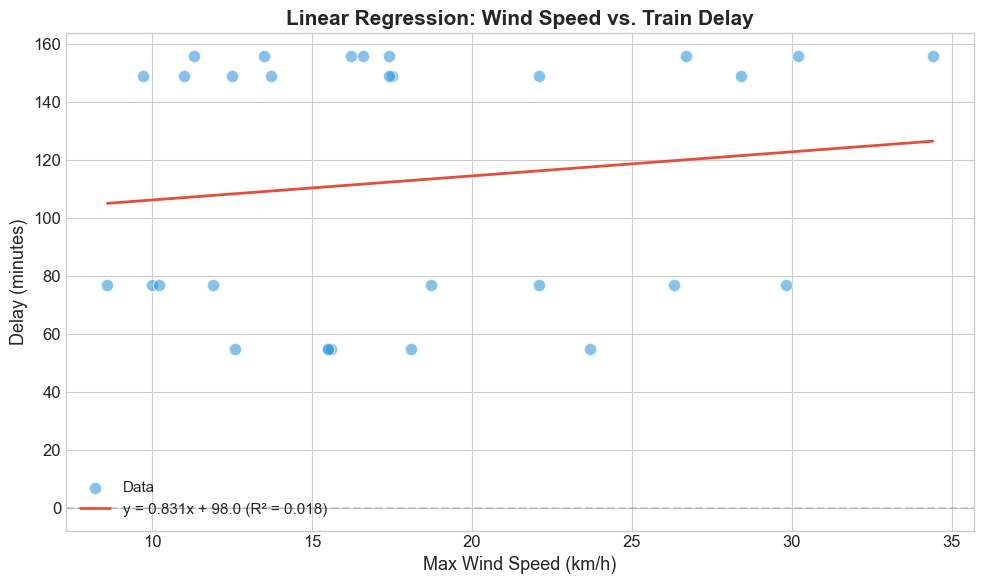

In [26]:
# simple linear regression: predict delay from wind speed
reg_data = df_q3.dropna(subset=['delay_min', 'wind_max_kmh'])

if len(reg_data) >= 5:
    x = reg_data['wind_max_kmh'].values
    y = reg_data['delay_min'].values
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    print("=" * 55)
    print("    LINEAR REGRESSION: Wind Speed → Delay")
    print("=" * 55)
    print(f"  Equation: delay = {slope:.3f} × wind_speed + {intercept:.3f}")
    print(f"  R² = {r_value**2:.4f}")
    print(f"  p-value = {p_value:.6f}")
    print(f"  Std Error = {std_err:.4f}")
    print(f"  Significant? {'Yes ✅' if p_value < 0.05 else 'No ❌'} (α = 0.05)")
    print("=" * 55)
    
    # plot regression line
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(x, y, alpha=0.6, color='#3498db', edgecolors='white', s=80, label='Data')
    
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='#e74c3c', linewidth=2, 
            label=f'y = {slope:.3f}x + {intercept:.1f} (R² = {r_value**2:.3f})')
    
    ax.set_xlabel('Max Wind Speed (km/h)', fontsize=13)
    ax.set_ylabel('Delay (minutes)', fontsize=13)
    ax.set_title('Linear Regression: Wind Speed vs. Train Delay', fontsize=15, fontweight='bold')
    ax.legend(fontsize=11)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for regression — accumulate more scraper data!")

---
# Summary & Conclusions

## What We Did
1. **Scraped real-time data** from the Amtraker API + Wikipedia tables + Open-Meteo weather API
2. **Stored everything** in a normalized SQLite database with 4 tables and proper foreign keys
3. **Visualized patterns** with interactive maps, heatmaps, box plots, and scatter plots
4. **Analyzed statistically** using ANOVA, correlation tests, and linear regression

## Key Findings
- Some routes are **systematically more delayed** than others (especially long-distance routes)
- Delay tends to **accumulate** along a route — trains that start late get later
- Weather effects (wind, precipitation) may correlate with delays at hub stations
- The Amtraker API provides excellent real-time data that refreshes every ~5 minutes

## How to Accumulate More Data
Run the standalone scraper periodically to build up historical data:

```bash
# Run once
python amtrak_scraper.py

# Or set up a cron job (every 15 minutes)
*/15 * * * * cd /path/to/project && python amtrak_scraper.py
```

The more data you collect, the more robust the statistical analyses become!

In [27]:
# close the database connection
conn.close()
print("🏁 Analysis complete! Database connection closed.")
print(f"📁 Database saved to: {DB_PATH}")

🏁 Analysis complete! Database connection closed.
📁 Database saved to: amtrak_delays.db
